# Perona-Malik Gradient step-edge example

Explicit anisotropic diffusion followed by a gradient stage. This notebook creates a simple black-to-white step edge, runs the filter, and plots the result.


## How this filter works

Perona-Malik diffusion smooths the image iteratively while reducing diffusion across strong intensity changes. After diffusion, this filter takes a declared derivative stage, so the output is a gradient of the edge-preserved image.

### Paper reference

Use Perona and Malik's 1990 anisotropic-diffusion paper, DOI [10.1109/34.56205](https://doi.org/10.1109/34.56205). Links. [Anisotropic diffusion](https://en.wikipedia.org/wiki/Anisotropic_diffusion).


## Setup

Import the small set of tools used in this notebook. The autoreload lines help Jupyter pick up local source edits without restarting the kernel every time.


In [1]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import torch

from agfb_filters import ExecutionPath, get_filter_definition, run_filter

## Filter settings

Choose the filter settings here. The `definition` describes the filter, and the `path` chooses the matching execution path.


In [6]:
# Change these settings to try the filter.
iterations = 200
step_size = 0.15
kappa = 0.2
definition = get_filter_definition(
    "perona_malik_gradient", iterations=iterations, step_size=step_size, kappa=kappa
)
path = ExecutionPath.ITERATIVE

## Test image

Create a test image. By default this is a synthetic step edge. The commented block lets you replace it with your own image file path.


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

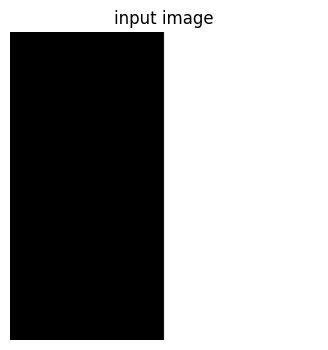

In [7]:
# Build the step-edge test image.
size = 1024
image = torch.zeros(1, size, size)
image[:, :, size // 2 :] = 1.0

# To use your own image instead, uncomment this block and set image_path.
# image_path = "path/to/image.png"
# image = torch.as_tensor(plt.imread(image_path), dtype=torch.float32)
# if image.ndim == 3:
#     image = image[..., :3].mean(dim=-1)
# image = image.unsqueeze(0)

plt.figure(figsize=(4, 4))
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.title("input image")
plt.axis("off")

## Run the filter

Run the filter. The timer measures only the filter call, not the image setup or plotting.


In [8]:
# Time the filter call.
start = time.perf_counter()
gradient_x, gradient_y = run_filter(
    definition,
    image,
    path=path,
    boundary=definition.default_boundary,
)
elapsed = time.perf_counter() - start

print(f"{elapsed:.4f} seconds")

1.0855 seconds


## Gradient results

Plot the two gradient outputs with the same grayscale range. The input changes left-to-right, so the strongest response should usually be in `gradient_x`.


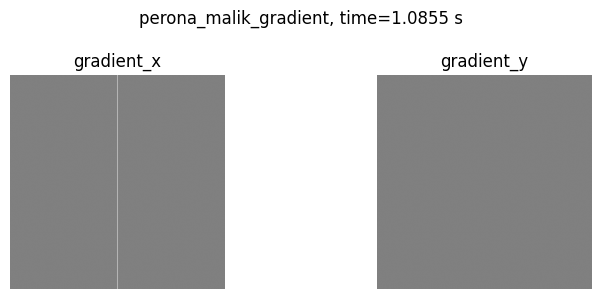

In [9]:
# Plot gradient_x and gradient_y.
limit = max(float(gradient_x.abs().max()), float(gradient_y.abs().max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(gradient_x[0], cmap="gray", vmin=-limit, vmax=limit)
axes[0].set_title("gradient_x")

axes[1].imshow(gradient_y[0], cmap="gray", vmin=-limit, vmax=limit)
axes[1].set_title("gradient_y")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"{definition.name}, time={elapsed:.4f} s")
fig.tight_layout()